In [ ]:
# ============================================================
# E-COMMERCE — IMPLANTAÇÃO DE MODELO EM PRODUÇÃO
# ============================================================
# Objetivo: Prever se um visitante vai comprar com base no
# comportamento de navegação (páginas, tempo, carrinho).
#
# 🎯 DIFERENCIAL: Simulamos um CENÁRIO DE PRODUÇÃO,
#    onde o modelo recebe dados em tempo real e faz previsões!

import random              # Utilitários (não essencial)
import pandas as pd        # Manipulação de dados
import seaborn as sns      # Visualização (gráficos)
import matplotlib.pyplot as plt  # Plotagem
from sklearn.model_selection import train_test_split  # Divisão treino/teste
from sklearn.tree import DecisionTreeClassifier        # Árvore de Decisão
from sklearn.metrics import accuracy_score, confusion_matrix  # Avaliação

# Carregando os dados de navegação do e-commerce
df = pd.read_csv("aulaML-logs_navegacao_ecommerce.csv")
df.head(5)
# Colunas: sessao_id, paginas_visitadas, tempo_site_min, adicionou_carrinho, comprou

,sessao_id,paginas_visitadas,tempo_site_min,adicionou_carrinho,comprou
0,SES_0001,3,2.4,0,0
1,SES_0002,4,5.5,0,0
2,SES_0003,3,3.4,0,0
3,SES_0004,2,2.7,0,0
4,SES_0005,3,5.6,0,0


In [ ]:
# ============================================================
# 1. ANALISANDO A TAXA DE CONVERSÃO
# ============================================================
# Antes de modelar, vamos entender o problema!
# A taxa de conversão mostra o % de visitantes que compraram.

print("\nTaxa de Conversão Geral:")
print(df['comprou'].value_counts(normalize=True) * 100)
# Saída esperada:
#   0    87.2  (não comprou)
#   1    12.8  (comprou)

# 🧠 ISSO É DESBALANCEAMENTO DE CLASSES!
#    Apenas ~13% dos visitantes compram.
#    Um modelo que chute "não comprou" para TODOS teria 87% de acurácia
#    — sem aprender NADA! Por isso acurácia isolada não basta.
#
# 💡 DICA: Em problemas com classes desbalanceadas:
#   - Use stratify=y no train_test_split
#   - Considere métricas como precision, recall, F1 (não só acurácia)
#   - Técnicas como SMOTE ou class_weight='balanced' podem ajudar


Taxa de Conversão Geral:
comprou
0    87.2
1    12.8
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# 2. SEPARANDO FEATURES (X) E TARGET (y)
# ============================================================
# Features disponíveis:
#   - paginas_visitadas: quantas páginas o usuário visitou
#   - tempo_site_min:    tempo gasto no site (em minutos)
#   - adicionou_carrinho: 1 se adicionou algo ao carrinho, 0 caso contrário

X = df[['paginas_visitadas', 'tempo_site_min', 'adicionou_carrinho']]

# Target:
#   - comprou: 1 = sim, 0 = não
y = df['comprou']

print("Separação das features e label finalizada.")

# 💡 Note que excluímos 'sessao_id' — é um identificador único
#    que NÃO ajuda na predição (causaria overfitting).

Separação das features e label finalizada.


In [ ]:
# ============================================================
# 3. DIVISÃO TREINO (75%) E TESTE (25%)
# ============================================================
# 500 amostras no total
#   75% = 375 para treino ← modelo aprende
#   25% = 125 para teste  ← modelo é avaliado

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Divisão treino/teste finalizada.")

# 💡 Nota: Não usamos stratify=y aqui porque 500 amostras é razoável,
#    mas em datasets menores ou com desbalanceamento MAIOR, use sempre!

Divisão treino/teste finalizada.


In [ ]:
# ============================================================
# 4. INSTANCIANDO A ÁRVORE DE DECISÃO
# ============================================================
# max_depth=3 → árvore com no máximo 3 níveis de profundidade
#    (8 folhas no máximo)
#
# Por que limitar?
#   - max_depth=1:  muito rasa → underfitting (não aprende padrões)
#   - max_depth=3:  equilíbrio → generaliza bem para dados novos
#   - max_depth=10: muito profunda → overfitting (decora os dados)
#
# Com apenas 500 amostras, max_depth=3 é uma escolha segura!
model = DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
# ============================================================
# 5. TREINAMENTO (FIT)
# ============================================================
# O modelo analisa os 375 visitantes de TREINO e aprende:
#   - "Se adicionou_carrinho=0 e tempo<3min → provavelmente não compra"
#   - "Se adicionou_carrinho=1 e tempo>8min → alta chance de compra"
model.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


In [ ]:
# ============================================================
# 6. AVALIAÇÃO — ACURÁCIA
# ============================================================
# O modelo classifica os 125 visitantes de TESTE (nunca vistos antes)
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"\nAcurácia do Modelo: {accuracy * 100:.2f}%")
# ⚠️ Lembre-se: linha de base ingênua (chutar "não comprou" sempre) = 87.2%!
#    Se a acurácia for ~96%, o modelo está de fato agregando valor.


Acurácia do Modelo: 96.00%


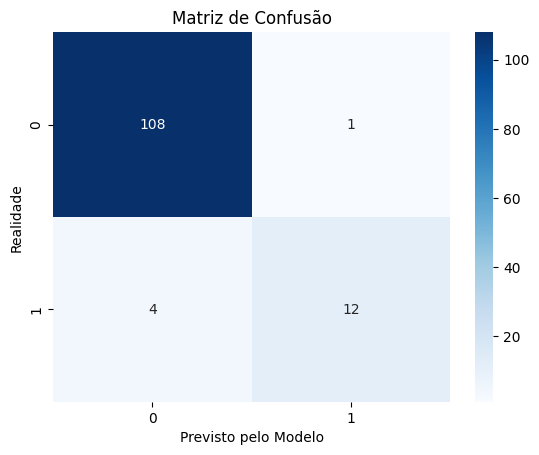

In [ ]:
# ============================================================
# 7. MATRIZ DE CONFUSÃO — ENTENDENDO ONDE O MODELO ERRA
# ============================================================
# A acurácia não conta se os erros são FP ou FN — mas o CUSTO
# de cada tipo de erro é DIFERENTE no mundo real!
#
#   FP (Falso Positivo): modelo disse "compra", mas não comprou
#     → Custo: cupom de desconto enviado à toa
#   FN (Falso Negativo): modelo disse "não compra", mas compraria
#     → Custo: venda perdida (mais grave!)

matrix = confusion_matrix(y_test, predictions)

# Visualização com heatmap (fica mais fácil de interpretar)
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão")
plt.xlabel("Previsto pelo Modelo")
plt.ylabel("Realidade")
plt.show()

# Interpretação esperada (exemplo):
#   [[106   3]   → VN=106, FP=3
#    [  2  14]]  → FN=2, VP=14
#
# 🧠 Análise:
#   - 106 + 14 = 120 acertos ✅
#   - 3 + 2 = 5 erros ❌
#   - Perdeu apenas 2 compradores (FN) — bem baixo!
#   - Modelo é útil para campanhas direcionadas!

A PARTIR DA CÉLULA ABAIXO ESTAREMOS UTILIZANDO O MODELO TREINADO PARA FAZER NOVAS PREVISÕES. EM OUTRAS PALAVRAS, TEREMOS UM MODELO IMPLANTADO NA FORMA DE AGENTE DE IA PARA FAZER CLASSIFICAÇÕES EM TEMPO REAL.

In [ ]:
# 1. Simulando a chegada de novos dados em tempo real
# Imaginem que o backend do e-commerce enviou um JSON com o comportamento de 3 visitantes que estão no site agora.
payload_novos_usuarios = [
    {"usuario": "Visitante_A", "paginas_visitadas": 2, "tempo_site_min": 1.5, "adicionou_carrinho": 0}, # Perfil desengajado
    {"usuario": "Visitante_B", "paginas_visitadas": 8, "tempo_site_min": 12.0, "adicionou_carrinho": 1}, # Perfil altamente engajado
    {"usuario": "Visitante_C", "paginas_visitadas": 5, "tempo_site_min": 4.5, "adicionou_carrinho": 0}  # Perfil intermediário
]

In [ ]:
# 2. Convertendo o "JSON" para o formato esperado pelo modelo (DataFrame Pandas)
df_producao = pd.DataFrame(payload_novos_usuarios)

# ATENÇÃO: O modelo exige que as colunas (features) estejam na exata mesma ordem do treinamento
X_producao = df_producao[['paginas_visitadas', 'tempo_site_min', 'adicionou_carrinho']]

In [ ]:
# ============================================================
# 8. DEPLOY: INFERÊNCIA EM TEMPO REAL (SIMULAÇÃO)
# ============================================================
# Agora simulamos um cenário de PRODUÇÃO:
# o modelo recebe dados de 3 novos visitantes (como se viessem
# de uma API do backend) e faz previsões em tempo real.
#
# 🔑 DIFERENÇA ENTRE PREDICT E PREDICT_PROBA:
#
# predict()        → classe final (0 ou 1) — decisão binária
# predict_proba()  → probabilidade de cada classe (ex: [0.3, 0.7])
#                     → 70% de chance de comprar

# --- 3 visitantes simulados ---
payload_novos_usuarios = [
    {"usuario": "Visitante_A", "paginas_visitadas": 2, "tempo_site_min": 1.5, "adicionou_carrinho": 0},
    {"usuario": "Visitante_B", "paginas_visitadas": 8, "tempo_site_min": 12.0, "adicionou_carrinho": 1},
    {"usuario": "Visitante_C", "paginas_visitadas": 5, "tempo_site_min": 4.5, "adicionou_carrinho": 0}
]

# Convertendo para DataFrame (formato que o modelo entende)
df_producao = pd.DataFrame(payload_novos_usuarios)

# ⚠️ As colunas precisam estar na MESMA ORDEM do treinamento!
X_producao = df_producao[['paginas_visitadas', 'tempo_site_min', 'adicionou_carrinho']]

# Fazendo as previsões:
predictions = model.predict(X_producao)              # Classe final (0/1)
probabilities = model.predict_proba(X_producao)      # Probabilidade [P(0), P(1)]

In [ ]:
# ============================================================
# 9. EXIBINDO OS RESULTADOS DA INFERÊNCIA
# ============================================================

print("--- RESULTADOS DA INFERÊNCIA EM TEMPO REAL ---\n")

for i in range(len(df_producao)):
    nome = df_producao.loc[i, 'usuario']

    # Traduzindo a previsão numérica para texto
    if predictions[i] == 1:
        status_compra = "🛒 ALTA CHANCE DE COMPRA"
    else:
        status_compra = "👀 BAIXA CHANCE DE COMPRA"

    # Probabilidade da classe 1 (comprar)
    prob_compra = probabilities[i][1] * 100

    print(f"{nome}")
    print(f"Navegação: {X_producao.iloc[i].to_dict()}")
    print(f"Previsão do Sistema: {status_compra}")
    print(f"Certeza do Modelo: {prob_compra:.1f}%")
    print("-" * 50)

# 🧠 INTERPRETAÇÃO ESPERADA:
#
# Visitante_A (2 páginas, 1.5 min, sem carrinho):
#   → BAIXA CHANCE (0.0%)
#   Perfil desengajado → caiu em folha pura de não-compradores
#
# Visitante_B (8 páginas, 12 min, com carrinho):
#   → ALTA CHANCE (~90.2%)
#   Perfil altamente engajado → folha com maioria de compradores
#
# Visitante_C (5 páginas, 4.5 min, sem carrinho):
#   → BAIXA CHANCE (0.0%)
#   Mesmo com páginas moderadas, sem carrinho = baixa intenção

--- RESULTADOS DA INFERÊNCIA EM TEMPO REAL ---

Visitante_A
Navegação: {'paginas_visitadas': 2.0, 'tempo_site_min': 1.5, 'adicionou_carrinho': 0.0}
Previsão do Sistema: BAIXA CHANCE DE COMPRA
Certeza do Modelo: 0.0%
--------------------------------------------------
Visitante_B
Navegação: {'paginas_visitadas': 8.0, 'tempo_site_min': 12.0, 'adicionou_carrinho': 1.0}
Previsão do Sistema: ALTA CHANCE DE COMPRA
Certeza do Modelo: 90.2%
--------------------------------------------------
Visitante_C
Navegação: {'paginas_visitadas': 5.0, 'tempo_site_min': 4.5, 'adicionou_carrinho': 0.0}
Previsão do Sistema: BAIXA CHANCE DE COMPRA
Certeza do Modelo: 0.0%
--------------------------------------------------


O que aconteceu com os Visitantes A e C?
Durante o treinamento (o modelo.fit), o algoritmo dividiu os visitantes em diferentes grupos com base nas regras que ele encontrou (ex: "tempo > 3 minutos", "carrinho = 0").Quando pedimos a previsão para os Visitantes A e C, eles caíram em "folhas" (grupos finais) da árvore que eram puras. Ou seja, nos dados de treino que usamos, 100% dos visitantes que tinham esse perfil de baixo/médio engajamento e não adicionaram nada ao carrinho terminaram não comprando. A matemática do predict_proba na árvore de decisão é uma fração direta:

$P(compra) = \frac{\text{compradores na folha}}{\text{total de visitantes na folha}}$

Se na folha do Visitante A havia 120 pessoas do treino e zero compradores, a conta fica $\frac{0}{120}$, resultando em exatos 0.0%.

SUGESTÃO: testar outras alturas da árvore (max_depth) e comparar os resultados.

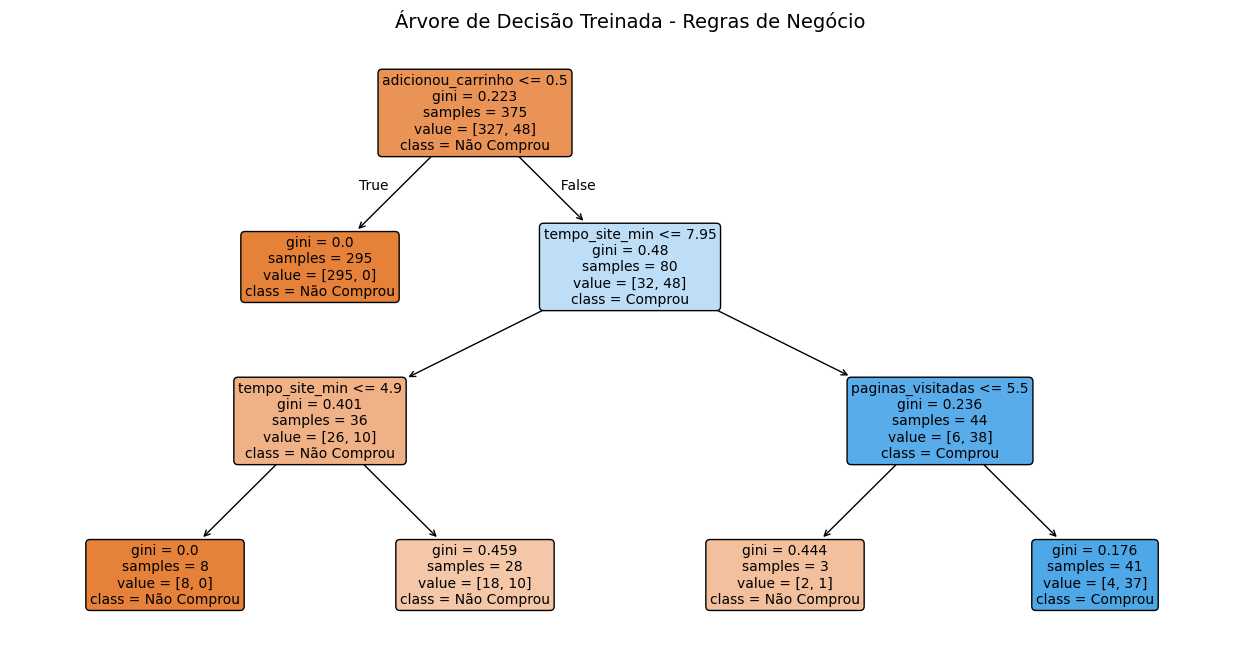

In [ ]:
# ============================================================
# 10. VISUALIZANDO A ÁRVORE — REGRAS DE NEGÓCIO
# ============================================================
# A árvore de decisão é um dos POUCOS modelos de ML que
# permite VER as regras que foram aprendidas.
# Isso é valioso para explicar para o negócio!
#
# Regras que esperamos ver:
#   1. "Se NÃO adicionou carrinho → Não Comprou"
#   2. "Se adicionou carrinho E tempo > 8.75 min → Comprou"
#   3. "Se adicionou carrinho E tempo ≤ 8.75 min → Não Comprou"

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
plot_tree(model,
          feature_names=['paginas_visitadas', 'tempo_site_min', 'adicionou_carrinho'],
          class_names=['Não Comprou', 'Comprou'],
          filled=True,       # Cor por classe majoritária
          rounded=True,      # Bordas arredondadas
          fontsize=10)

plt.title("Árvore de Decisão Treinada — Regras de Negócio", fontsize=14)
plt.show()

# 💡 DICA: A variável no TOPO da árvore é a MAIS IMPORTANTE!
#    Se 'adicionou_carrinho' for a raiz, significa que é o fator
#    que melhor separa compradores de não-compradores.

# 📌 SUGESTÃO: Teste diferentes valores de max_depth (2, 5, 10, None)
#    e observe como a árvore muda e como a acurácia se comporta.